# 11. 基于遮蔽攻击的对抗性训练

## 11.0 主要内容介绍

在之前的实验中，我们学习了基于模型可解释性之梯度积分法的遮蔽攻击（Inductive Occlusion Attack, IOA），以及基于PGD攻击的对抗性训练。

在本节中，我们将在MNIST数据集上实现遮蔽攻击，并基于遮蔽攻击进行专门的对抗性训练，以提升模型对遮蔽攻击的鲁棒性。

本实验的主要内容为采用Python、PyTorch、Captum等技术，实现基于遮蔽攻击的对抗性训练，并进行鲁棒性测试。

## 11.1 导入相关模块

In [1]:
import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import logging

from tabulate import tabulate
import test; test_fn = test.test
from loss import LabelSmoothingCrossEntropyLoss, CWLoss
from pgd import LinfPGD
from occlusion_attack import OcclusionAttack
from adversarial_training import OcclusionAdversarialTraining
from utils import load_mnist_test
from models import LeNet5, FCNet


logger = logging.getLogger('base')
logger.setLevel(logging.DEBUG)

formatter = logging.Formatter(fmt='%(process)6d %(asctime)s %(message)s', datefmt='%Y%m%d %H:%M:%S')
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.DEBUG)
stream_handler.setFormatter(formatter)

logger.addHandler(stream_handler)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 11.2 遮蔽攻击（Inductive Occlusion Attack）在MNIST上的实现

遮蔽攻击的核心思想是利用梯度积分（Integrated Gradients）来确定图像中最重要的区域，然后用特定颜色的遮蔽块覆盖这些区域，从而欺骗模型。

具体步骤为：
1. 使用梯度积分计算每个像素的重要性
2. 通过卷积操作计算每个区域的重要性之和
3. 选择最重要的top_k个区域中心
4. 用kernel_size × kernel_size的遮蔽窗口覆盖这些区域

与CIFAR-10上的实现不同，MNIST为单通道灰度图像（1×28×28），因此在卷积操作中输入通道数为1。

### 11.2.1 加载标准模型并测试遮蔽攻击效果

In [2]:
# 加载标准训练的LeNet5模型
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth')
std_lenet = LeNet5()
std_lenet.load_state_dict(std_state['net'])
std_lenet = std_lenet.to(device)
std_lenet.eval()

print('标准LeNet5模型加载完成')

标准LeNet5模型加载完成


C:\Users\31198\AppData\Local\Temp\ipykernel_32996\3247200306.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  std_state = torch.load('./save_model/50epoch/mnist_lenet5.pt

In [3]:
# 加载MNIST测试集
imgs, lbls = load_mnist_test()

# 测试标准模型在干净样本上的准确率
cln_acc, _ = test_fn(std_lenet, imgs, lbls, bs=250, mode='clean')
logger.info(f'标准模型 - 干净样本准确率: {cln_acc:.2f}%')

 32996 20260315 23:37:31 标准模型 - 干净样本准确率: 99.00%


In [4]:
# 测试遮蔽攻击对标准模型的效果
occlusion = OcclusionAttack(std_lenet, top_k=9, occlu_color=0.0, kernel_size=3)
occ_acc, _ = test_fn(nn.Sequential(occlusion, std_lenet), imgs, lbls, bs=250, mode='attack')
logger.info(f'标准模型 - 遮蔽攻击后准确率: {occ_acc:.2f}%')

 32996 20260315 23:37:39 标准模型 - 遮蔽攻击后准确率: 28.64%


真实标签: 9


d:\anaconda3\envs\adv-attack\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24178 (\N{CJK UNIFIED IDEOGRAPH-5E72}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\adv-attack\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20928 (\N{CJK UNIFIED IDEOGRAPH-51C0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\adv-attack\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\adv-attack\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


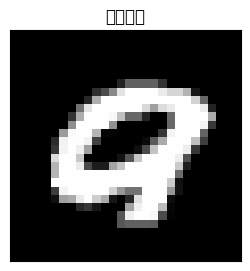

d:\anaconda3\envs\adv-attack\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36974 (\N{CJK UNIFIED IDEOGRAPH-906E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\adv-attack\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 34109 (\N{CJK UNIFIED IDEOGRAPH-853D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\adv-attack\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25915 (\N{CJK UNIFIED IDEOGRAPH-653B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\adv-attack\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20987 (\N{CJK UNIFIED IDEOGRAPH-51FB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


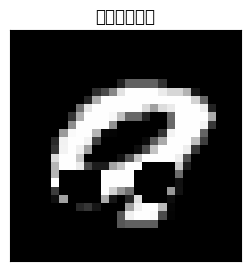

In [5]:
# 可视化遮蔽攻击效果
def imshow_mnist(img, title=''):
    npimg = img.cpu().squeeze().numpy()
    plt.figure(figsize=(3, 3))
    plt.imshow(npimg, cmap='gray')
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.show()

# 取一个batch进行可视化
sample_x = imgs[:250].to(device)
sample_y = lbls[:250].to(device)
std_lenet.eval()
sample_adv = occlusion((sample_x, sample_y))

idx = 0
print(f'真实标签: {sample_y[idx].item()}')
imshow_mnist(sample_x[idx], '干净样本')
imshow_mnist(sample_adv[idx], '遮蔽攻击样本')

## 11.3 基于遮蔽攻击的对抗性训练

与PGD对抗性训练类似，基于遮蔽攻击的对抗性训练在每个训练步骤中：
1. 先对输入样本执行遮蔽攻击，生成对抗性样本
2. 然后用对抗性样本进行模型训练

通过OcclusionAdversarialTraining类，我们可以复用原有的训练代码，只需替换攻击方式即可。

In [6]:
# 超参数
EPOCH = 50              # 训练总epoch数
BATCH_SIZE = 256        # 训练batch size大小
LR = 0.001              # 初始学习率
DOWNLOAD_MNIST = False  # 是否下载数据集（已下载设置为False）

TOP_K = 9               # 遮蔽攻击的top_k参数
OCCLU_COLOR = 0.0       # 遮蔽颜色（黑色）
KERNEL_SIZE = 3         # 遮蔽窗口大小

if not(os.path.exists('./data/')) or not os.listdir('./data/'):
    DOWNLOAD_MNIST = True

In [7]:
# 导入数据，定义数据接口
train_dataset = torchvision.datasets.MNIST(
    root="./data/", train=True, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.MNIST(
    root="./data/", train=False, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

In [8]:
# 定义网络结构
cnn = LeNet5().to(device)
print(cnn)

# 使用Adam Optimizer
optimizer = torch.optim.Adam(cnn.parameters(), lr=LR)

# 配置损失函数
loss_function = nn.CrossEntropyLoss()

num_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print('模型参数大小为：', num_params)

LeNet5(
  (conv1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
  )
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
模型参数大小为： 61706


In [9]:
# 构建基于遮蔽攻击的对抗性训练模型
cnn_oat = OcclusionAdversarialTraining(
    cnn, top_k=TOP_K, occlu_color=OCCLU_COLOR, kernel_size=KERNEL_SIZE, is_at=True)

In [ ]:
"""
    在cnn_oat.is_at = True的前提下，cnn_oat将先对输入的任何样本进行遮蔽攻击再进行测试。
因此，此处的train_accs, train_losses, test_accs, test_losses与以往实验中的含义不
同，它们均为经过遮蔽攻击后的指标。
"""
train_accs = []
train_losses = []
test_accs = []
test_losses = []

for epoch in range(EPOCH):
    # 训练
    cnn_oat.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        n = labels.size(0)
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = cnn_oat(inputs, labels)

        loss = loss_function(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pred = outputs.max(dim=1).indices        
        train_total += n
        train_correct += (pred == labels).sum().item()
        train_loss += loss.data.item() * n
        
    train_accs.append(train_correct / train_total)
    train_losses.append(train_loss / train_total)
    logger.info(f'training epoch: {epoch}, loss: {train_loss / train_total:.2f}, acc: {100 * train_correct / train_total:.2f}%')

    # 测试
    cnn_oat.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(test_loader):
            n = labels.size(0)

            inputs, labels = inputs.to(device), labels.to(device)
            outputs = cnn_oat(inputs, labels)
            loss = loss_function(outputs, labels)

            pred = outputs.max(dim=1).indices  
            test_correct += (pred == labels).sum().item()
            test_total += n
            test_loss += loss.data.item() * n

    test_accs.append(test_correct / test_total)
    test_losses.append(test_loss / test_total)

    logger.info(f'    test epoch: {epoch}, loss: {test_loss / test_total:.2f}, acc: {100 * test_correct / test_total:.2f}%')

 32996 20260315 23:38:36 training epoch: 0, loss: 1.17, acc: 60.94%
 32996 20260315 23:38:45     test epoch: 0, loss: 0.73, acc: 75.70%
 32996 20260315 23:39:38 training epoch: 1, loss: 0.62, acc: 79.80%
 32996 20260315 23:39:47     test epoch: 1, loss: 0.52, acc: 82.89%
 32996 20260315 23:40:41 training epoch: 2, loss: 0.46, acc: 84.98%
 32996 20260315 23:40:51     test epoch: 2, loss: 0.38, acc: 87.63%
 32996 20260315 23:41:45 training epoch: 3, loss: 0.36, acc: 88.36%
 32996 20260315 23:41:54     test epoch: 3, loss: 0.33, acc: 89.02%
 32996 20260315 23:42:49 training epoch: 4, loss: 0.29, acc: 90.42%
 32996 20260315 23:42:59     test epoch: 4, loss: 0.25, acc: 91.56%


In [ ]:
# 保存模型
state = {
    'net': cnn.state_dict(),
    'num_epoch': epoch,
    'train_losses': train_losses,
    'train_accs': train_accs,
    'test_losses': test_losses,
    'test_accs': test_accs,
}

result_path = f'./save_model/' + str(EPOCH) + 'epoch'
if not os.path.isdir(result_path):
    os.makedirs(result_path)
torch.save(state, result_path + f'/mnist_lenet5_OcclusionAT_{TOP_K}_{KERNEL_SIZE}.pth')

In [ ]:
plt.figure(figsize=(15, 5))

idx = [_ for _ in range(EPOCH)]
plt.subplot(1, 2, 1)
plt.plot(idx, train_accs, label='training')
plt.plot(idx, test_accs, label='test')
plt.legend()
plt.title('Robust Accuracy')

plt.subplot(1, 2, 2)
plt.plot(idx, train_losses, label='training')
plt.plot(idx, test_losses, label='test')
plt.legend()
plt.title('Robust Loss')

plt.show()

## 11.4 鲁棒性测试

### 11.4.0 遮蔽攻击测试

In [ ]:
# 加载样本
imgs, lbls = load_mnist_test()

# 遮蔽攻击测试
occlusion = OcclusionAttack(cnn, top_k=TOP_K, occlu_color=OCCLU_COLOR, kernel_size=KERNEL_SIZE)

cln_acc, _ = test_fn(cnn, imgs, lbls, bs=250, mode='clean')
occ_acc, _ = test_fn(nn.Sequential(occlusion, cnn), imgs, lbls, bs=250, mode='attack')

logger.info(f'遮蔽攻击AT模型 - Clean: {cln_acc:.2f}, Occlusion Attack: {occ_acc:.2f}')

### 11.4.1 白盒攻击测试（PGD, FGSM, CW）

In [ ]:
EPS = 0.1

# 定义攻击参数
FGSM_kwargs = dict(net=cnn, eps=EPS, step=1, step_size=EPS, random_start=False)
PGD_kwargs = dict(net=cnn, eps=EPS, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=cnn, eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 执行测试
fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn), imgs, lbls, bs=250, mode='attack')
pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn), imgs, lbls, bs=250, mode='attack')
cw_acc, _ = test_fn(nn.Sequential(CW, cnn), imgs, lbls, bs=250, mode='attack')

logger.info(f'遮蔽攻击AT模型 - Clean: {cln_acc:.2f}, FGSM: {fgsm_acc:.2f}, PGD: {pgd_acc:.2f}, CW: {cw_acc:.2f}, Occlusion: {occ_acc:.2f}')

### 11.4.2 迁移攻击测试

In [ ]:
# 使用标准模型作为替代模型进行迁移攻击
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth')
std_lenet = LeNet5()
std_lenet.load_state_dict(std_state['net'])
std_lenet = std_lenet.to(device)
std_lenet.eval()

# 定义迁移攻击参数（基于标准模型生成对抗性样本，测试遮蔽攻击AT模型）
FGSM_kwargs = dict(net=std_lenet, eps=EPS, step=1, step_size=EPS, random_start=False)
PGD_kwargs = dict(net=std_lenet, eps=EPS, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=std_lenet, eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 遮蔽迁移攻击
occlusion_transfer = OcclusionAttack(std_lenet, top_k=TOP_K, occlu_color=OCCLU_COLOR, kernel_size=KERNEL_SIZE)

# 执行迁移攻击测试
trans_fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn), imgs, lbls, bs=250, mode='attack')
trans_pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn), imgs, lbls, bs=250, mode='attack')
trans_cw_acc, _ = test_fn(nn.Sequential(CW, cnn), imgs, lbls, bs=250, mode='attack')
trans_occ_acc, _ = test_fn(nn.Sequential(occlusion_transfer, cnn), imgs, lbls, bs=250, mode='attack')

logger.info(f'迁移攻击 - FGSM: {trans_fgsm_acc:.2f}, PGD: {trans_pgd_acc:.2f}, CW: {trans_cw_acc:.2f}, Occlusion: {trans_occ_acc:.2f}')

### 11.4.3 结果汇总

In [ ]:
headers = ['模型', 'Clean', 'FGSM', 'PGD', 'CW', 'Occlusion']
table = [
    ['遮蔽攻击AT (白盒)', f'{cln_acc:.2f}', f'{fgsm_acc:.2f}', f'{pgd_acc:.2f}', f'{cw_acc:.2f}', f'{occ_acc:.2f}'],
    ['遮蔽攻击AT (迁移)', f'{cln_acc:.2f}', f'{trans_fgsm_acc:.2f}', f'{trans_pgd_acc:.2f}', f'{trans_cw_acc:.2f}', f'{trans_occ_acc:.2f}'],
]
print(tabulate(table, headers=headers, tablefmt='grid'))